### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
from scipy.interpolate import interp1d
import ruptures as rpt
from sklearn.model_selection import train_test_split




path='/home/jbohn/jupyter/personal/'
sys.path.append(f'{path}TAQ-Query-Scripts/data')
sys.path.append(f'{path}Changepoint_LOB/Lasso/CPD')
from adaptive_tf import l1tf_adaptive, Dmat

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [2]:
trades=pd.read_csv(f'{path}TAQ-Query-Scripts/data/aapl_sample_trades.csv')
trades 
trades.index=pd.to_datetime(trades['Time'],format="%Y-%m-%d %H:%M:%S.%f")
trades=trades[trades.index < datetime.strptime(f"2018-01-02 16:00:00", "%Y-%m-%d %H:%M:%S")]
trades=trades[trades.index > datetime.strptime(f"2018-01-02 15:45:00", "%Y-%m-%d %H:%M:%S")]

Text(0.5, 1.0, 'APPL Trade Price 01/02/2020')

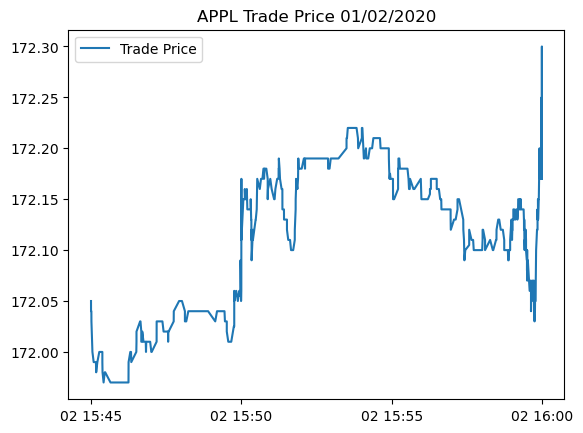

In [3]:
fig,ax=plt.subplots()
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/02/2020")

In [4]:
vol=trades['Trade_Volume']

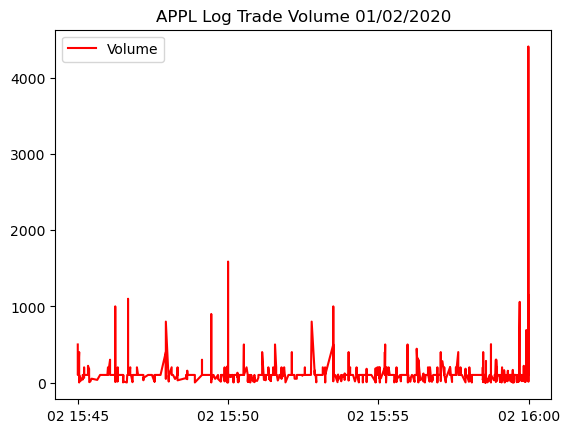

In [5]:
fig,ax=plt.subplots()
ax.set_title("APPL Log Trade Volume 01/02/2020")
ax.plot(vol,color='red',label='Volume')
ax.legend()

### Compute Max Lambda 

As denoted in L1 Trend Filtering, smallest maximum for which $\forall \lambda \geq \lambda_{max}$ the L1 trend filtering returns the best linear affine fit
$$\lambda_{max}=||(DD^T)^{-1}Dy||_\infty$$

For adaptiveness; one idea to show that the max of each component corresponds to the max of that single partition is that the trivial example of the best affine fit between two points simplify to linear interpolation

In [6]:
def max_norm(y,k=2,adaptive=False,verbose=True):
    
    '''
    
    Computes the smallest max penalty which provides a lower bound of linear affine fits 
    
    * More efficient ways to compute matrix inverses 
    * Condition number as proxy for ill-conditioned matrices 
    * Reasoning for near zero values at endpoints
    
    
    '''
    D=Dmat(len(y),k)
    D_DT=(np.linalg.inv(np.matmul(D,D.T)))
    
    if not adaptive:
        max_lam=np.max(abs(np.matmul(np.matmul(D_DT,D),y)))
    else:
        max_lam=abs(np.matmul(np.matmul(D_DT,D),y))
        
    if verbose:
        print("Condition Number is ",round(np.linalg.cond(np.matmul(D,D.T)),2))
    return max_lam

In [7]:
lambda_val=max_norm(trades['Trade_Price'].values,2)
lambda_val

Condition Number is  73637777600.53


5034.464959898739

Condition Number is  73637777600.53


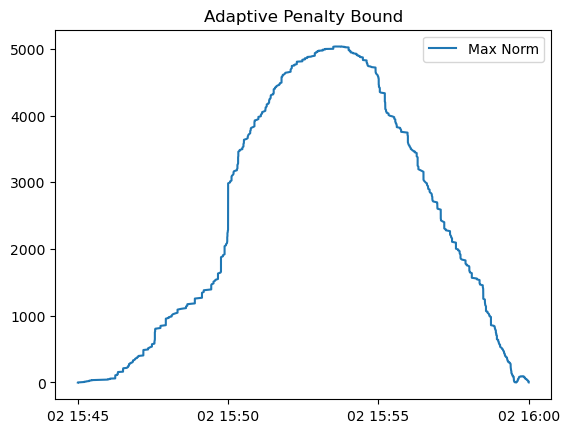

In [8]:
lambda_val=max_norm(trades['Trade_Price'].values,2,True)
plt.title("Adaptive Penalty Bound")

plt.plot(trades['Trade_Price'].index[1:-1],lambda_val,label='Max Norm')
plt.legend()

### Apply Kernel Smoothing on Volume Time Series

Applies Kernel Spatial Smoothing s.t. 

$$\hat{Y}(x_j)=\frac{\sum_{t=1}^T K_\sigma(x_i,x_j)Y(x_i)}{\sum_{t=1}^T K_\sigma(x_i,x_j)}$$ 

Where our kernel function is the Epanechnikov Kernel $K(u)=0.75(1-u^2)$

In [9]:
def compute_kernel(x_0,x_i,bandwidth):
    '''
    Given two points x_0 and x_i; compute the kernel
    '''
    scale=abs((x_0-x_i)/bandwidth) # absolute distance in time
    
    if scale <1:
    
        weight= 0.75*((1-scale)**2)
      
    else:
        weight=0
   
    return weight

def kernel_smooth(x0,series,pen,bandwidth,approach=1):
    '''
    x0: index of recent observation
    series: observations
    pen: max lambda to scale kernel to
    bandwidth: desired bandwidth param
    Approach: Style of KS under Constraints 

    '''
    num=0
    ker=0
    
    counter=0
    for index,val in series.items():
        
        kernel=compute_kernel(x0,index,bandwidth) # compute weight as a function of time 
        ker+=kernel
        if approach==1:
            num+=kernel*val # kernel smoothed series constrained by penalty 
        else:
            num+=kernel*pen[counter] # kernel smoothed penalty computed by series 
        counter+=1
    
            
        
    
    return (num/ker)

### Smoothing with Constraint under Adaptive Penalization

We want to constrain our kernel smoothed series to be less than the adaptive penalty vector such that our l1 trend filtering is in a penalty range constraining the smoothing

**Approach 1:** Normalize our smoothed series to the $q-th$ quantile of $sup(|p_t|)$
    - This respects the max of each component greater than some threshold
    - Rescales entire smoothing series to be within threshold of penalty vector
 
**Approach 2:** Applies Kernel smoothing directly to the penalty; not required to respect the constraint at each point
  

In [10]:
def smooth_series(k_series,p_series,scaled_k,bandwidth,quantile=None,approach=1,cv=True):
    
    '''
     
    Kernel Smooths a series under the condition to satisfy an exogenous variable (adaptive penalty)
    
    In this case the space of viable solutions are not unique so we need some condition to choose a viable one
     
    Approach 1
        Scales to qth quantile of max_norm (assuming a uniform distribution)
        
    Approach 2
        Applies Kernel directly on the Adaptive Penalties 
        
 
    '''
    
    thresh=1000 # threshold to ignore very small penalty params 
    smooth=[]
    pen=np.pad(max_norm(p_series.values,adaptive=True,verbose=False),(1,1))
       
    for x_i_index, x_i in k_series.items():
        smoothed_val=kernel_smooth(x_i_index,k_series,pen,bandwidth,approach )
        smooth.append(smoothed_val)
   
    smooth=pd.Series(smooth,index=k_series.index)
    
    # if approach 1 and we have finished cv; scale to q-th quantile of the penalty value observed at max
    if approach==1 and cv==True:
        index=np.where(pen>thresh)[0]
        scaled_p=1/np.max(np.divide(smooth.values[index],pen[index]))
        #scale by smallest ratio to ensure less than penalty up to threshold
        smooth=(smooth*scaled_p*quantile)
    
    #otherwise keep unadjusted to evaluate against test set
    else:
        pass
        
    return smooth


def cross_validate_bw(kernel_series,penalty_series,approach,seed=1234,train_size=0.75):
    
    '''
    kernel_series: Series we wish to apply kernel smoothing on
    penalty_series: Series we wish to compute adaptive penalty from
    approach: method for cv
    '''
    
    results={}
    grid=np.linspace(.1,100,10) # grid of bw params for kernel
    
    if approach==1:
        quantile=np.linspace(0.5,0.95,10) # quantile ranges for severity of penalty
        pairs= np.array([[{i:j} for i in grid]for  j in quantile]).flatten()
    else:
        pairs=grid

    old_index=kernel_series.index
    k_seconds=(kernel_series.index-kernel_series.index[0]).total_seconds() 
    kernel_series=pd.Series(kernel_series.values,index=k_seconds) # convert to total seconds elapsed 
    p_seconds=(penalty_series.index-penalty_series.index[0]).total_seconds() 
    penalty_series=pd.Series(penalty_series.values,index=p_seconds) # convert to total seconds elapsed 
    
    scaled_k=np.max(kernel_series)
    
    Xk_train, Xk_test, yk_train, yk_test = train_test_split(kernel_series.index,kernel_series.values,train_size=train_size,random_state=seed) # 90/10 split series to kernel smooth 
    Xk=pd.Series(yk_train,index=Xk_train).sort_index()
    Yk=pd.Series(yk_test,index=Xk_test).sort_index()  
        
    Xp_train, Xp_test, yp_train, yp_test = train_test_split(penalty_series.index,penalty_series.values,train_size=train_size,random_state=seed) # 90/10 split series to kernel smooth 
    Xp=pd.Series(yp_train,index=Xp_train).sort_index()
    Yp=pd.Series(yp_test,index=Xp_test).sort_index()  

    if approach==1:
        for k in pairs:
            bw=list(k.keys())[0]
            quantile=list(k.values())[0]
            
            smooth=smooth_series(Xk,Xp,scaled_k,bw,quantile,approach,cv=False)
            f=interp1d(Xk.index,smooth.values,kind='linear',fill_value='extrapolate') # assume lienar fit between smoothed observations 
            pred=np.sum((f(Yk.index)-Yk.values)**2)
            results[(bw,quantile)]=pred
            
        opt_param=sorted(results.items(), key=lambda x:x[1])[0]
        print(f"Optimal CV Bandwidth: {opt_param[0][0]} and Quantile {opt_param[0][1]}: Error {opt_param[1]}")
        cv_smooth=smooth_series(kernel_series,penalty_series,scaled_k,opt_param[0][0],opt_param[0][1],approach,cv=True)

    
    else:
        for k in pairs:
            
            bw=k
            smooth=smooth_series(Xk,Xp,scaled_k,bw,approach=approach,cv=False)
            f=interp1d(Xk.index,smooth.values,kind='linear',fill_value='extrapolate') # assume lienar fit between smoothed observations 
            pred=np.sum((f(Yk.index)-Yk.values)**2)
            results[k]=pred

        opt_param=sorted(results.items(), key=lambda x:x[1])[0][0]
        print(f"Optimal CV Bandwidth: {bw}")
        cv_smooth=smooth_series(kernel_series,penalty_series,scaled_k,opt_param,approach,cv=True)
        
    return pd.Series(cv_smooth.values,index=old_index)
        
    
    

In [11]:
smooth1=cross_validate_bw(vol,trades['Trade_Price'],1) # quantile based kernel smoothing

Optimal CV Bandwidth: 11.200000000000001 and Quantile 0.5: Error 24161131.482471265


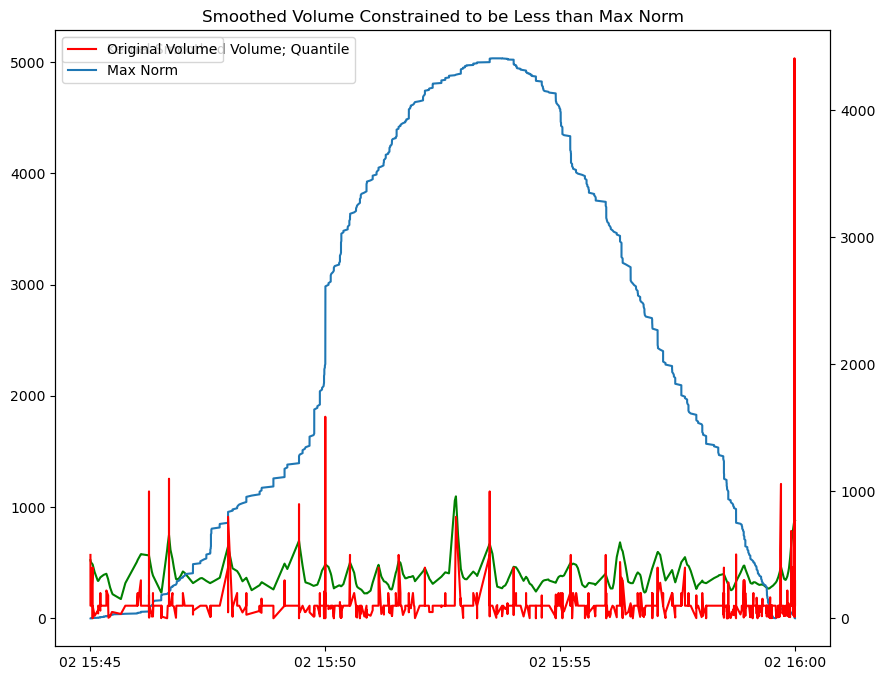

In [12]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(smooth1.index,smooth1.values,label='Kernel Smoothed Volume; Quantile',color='green')
ax.plot(smooth1.index[1:-1],lambda_val,label='Max Norm')
ax.set_title("Smoothed Volume Constrained to be Less than Max Norm")
ax2=ax.twinx()
ax2.plot(vol,color='red',label='Original Volume')
ax.legend()
ax2.legend(loc='upper left')

In [13]:
smooth2=cross_validate_bw(vol,trades['Trade_Price'],2) # kernel based smoothing on penalty function

Optimal CV Bandwidth: 100.0


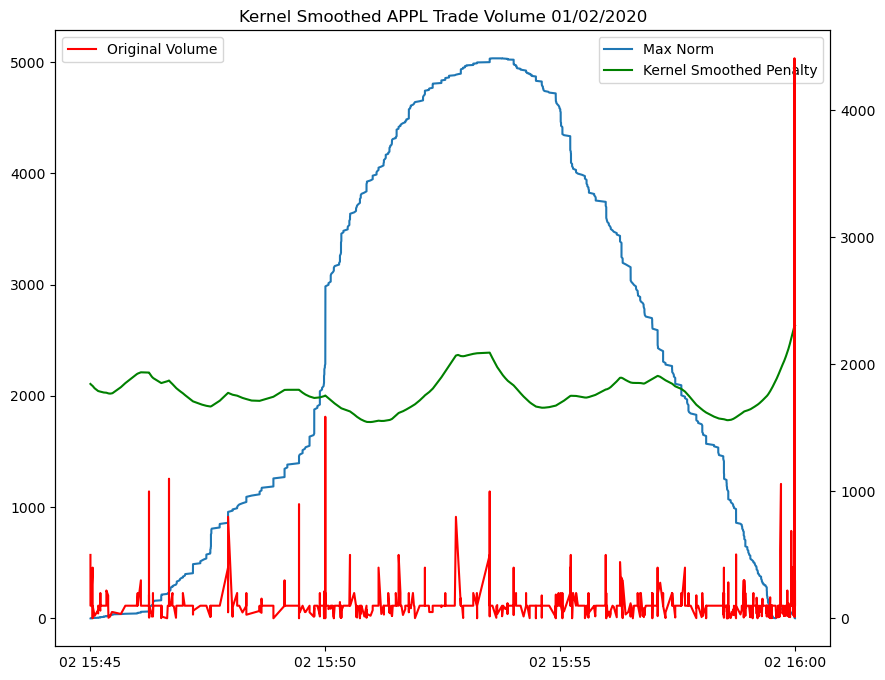

In [14]:
fig,ax=plt.subplots(figsize=(10,8))
ax.set_title("Kernel Smoothed APPL Trade Volume 01/02/2020")
ax.plot(trades['Trade_Price'].index[1:-1],lambda_val,label='Max Norm')

ax.plot(smooth2.index,smooth2.values,label='Kernel Smoothed Penalty',color='green')
ax.legend()

ax2=ax.twinx()
ax2.plot(vol,color='red',label='Original Volume')
ax.legend()
ax2.legend(loc='upper left')

### Changepoint Detection with Adaptive Penalty Strength for Exogenous Information
- The idea here is to apply a time dependent penalty method where strength is determined via a independent series 
- We will apply this with both methods of kernels discussed above

### Kernel 1

In [15]:
pen=smooth1.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)
x_adapt1,status,gap_adapt=l1tf_adaptive(y,lambda_p=pen)

solved


Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

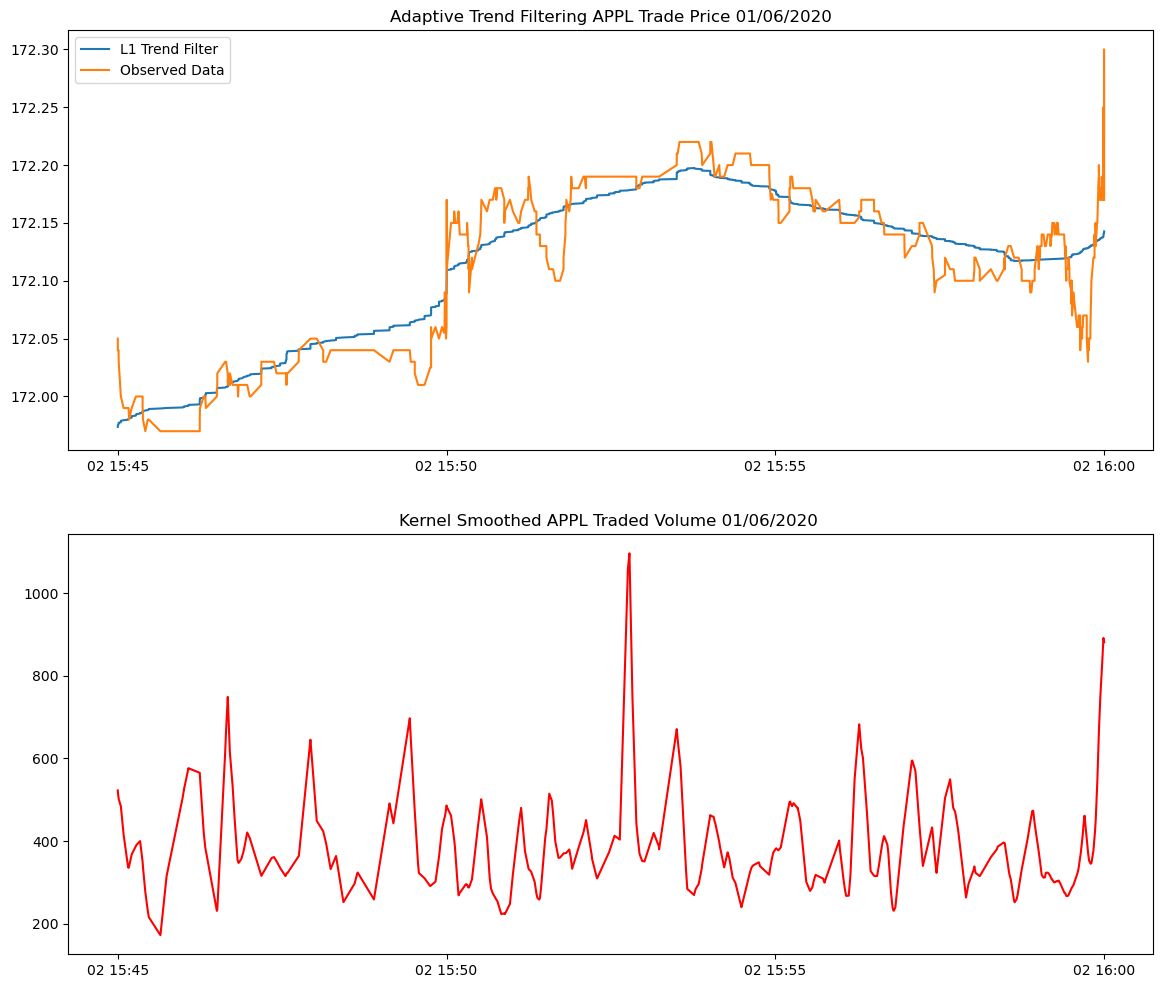

In [16]:
fig,ax=plt.subplots(2,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt1,label= 'L1 Trend Filter')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(smooth1,label='Volume',color='red')
ax[1].set_title('Kernel Smoothed APPL Traded Volume 01/06/2020 ')
ax[0].legend()
ax[0].set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Kernel 2

In [17]:
pen=smooth2.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)
x_adapt2,status,gap_adapt=l1tf_adaptive(y,lambda_p=pen)

solved


Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

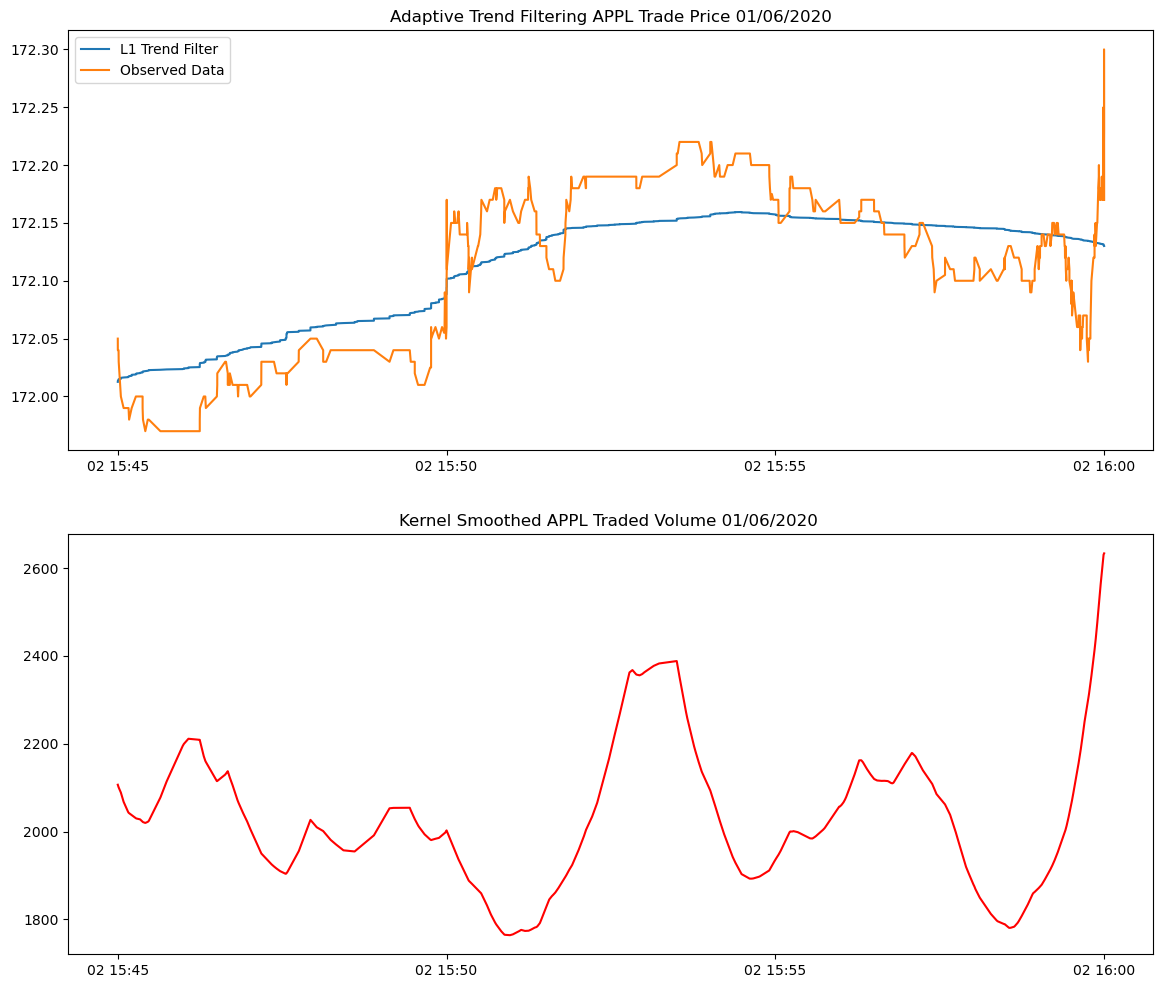

In [18]:
fig,ax=plt.subplots(2,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt2,label= 'L1 Trend Filter')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(smooth2,label='Volume',color='red')
ax[1].set_title('Kernel Smoothed APPL Traded Volume 01/06/2020 ')
ax[0].legend()
ax[0].set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

Text(0.5, 1.0, 'Difference in L1 Trend Filtering between Kernels')

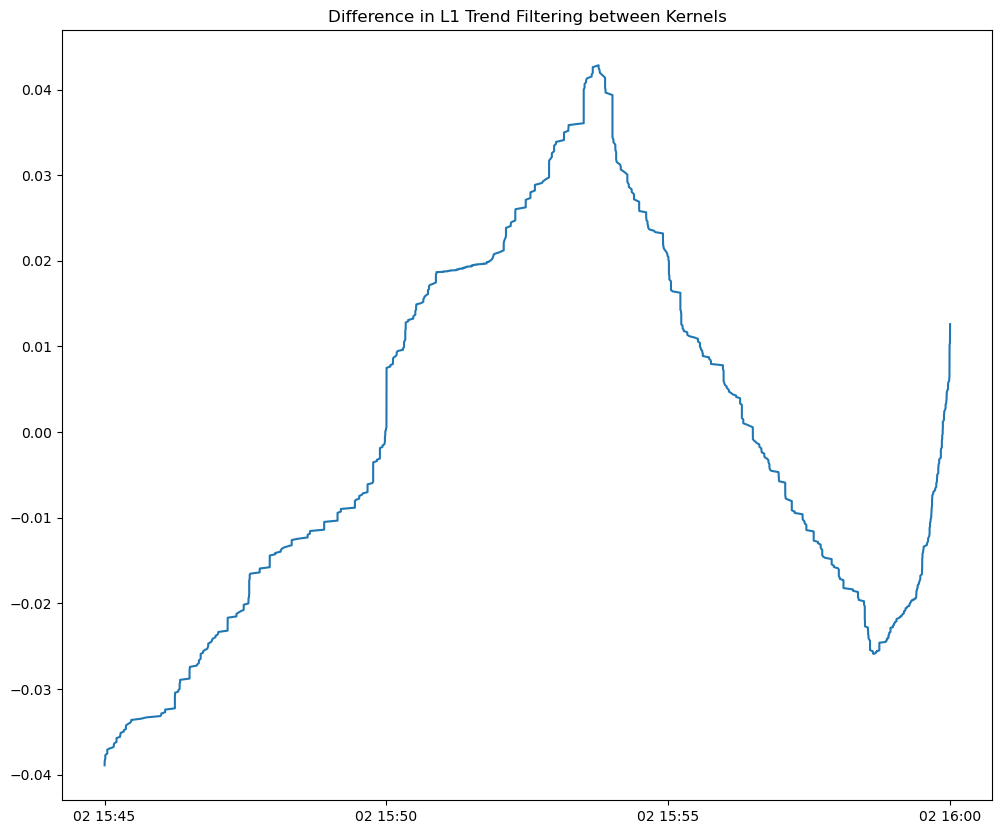

In [19]:
fig,ax=plt.subplots(figsize=(12,10))
diff=pd.Series((x_adapt1-x_adapt2).reshape(1,-1)[0],index=trades.index)
ax.plot(diff,label='Difference in Price')
ax.set_title("Difference in L1 Trend Filtering between Kernels")

### Changepoint Detection via Dynamic Programming 

Inspired via Levy-Leduc Formulation where we first compute changepoints for $K_{max}>>K$ using a LASSO Style Algorithm


We then utilize dynamic programming to determine best collection from candidate set